IMPORT LIBRARIES

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

LOAD DATASET

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Walmart sales dataset cleaned (new).csv to Walmart sales dataset cleaned (new).csv


READ THE DATASET

In [8]:
df = pd.read_csv("Walmart sales dataset cleaned (new).csv")

CREATE SQLITE DATABASE

In [9]:
df.to_sql("sales", conn, if_exists="replace", index=False)

print("Database created successfully")

conn.close()

Database created successfully


SQL QUERY

In [15]:
conn = sqlite3.connect("sales_data.db") # Re-establish connection

query = """
SELECT
    product_line AS product,
    SUM(quantity) AS total_qty,
    SUM(total) AS revenue
FROM sales
GROUP BY product_line
"""

sales_summary = pd.read_sql_query(query, conn)

print(sales_summary)

conn.close()

                  product  total_qty     revenue
0  Electronic accessories        961  53783.2365
1     Fashion accessories        902  54305.8950
2      Food and beverages        952  56144.8440
3       Health and beauty        844  48854.3790
4      Home and lifestyle        911  53861.9130
5       Sports and travel        902  53936.1270


BAR CHART

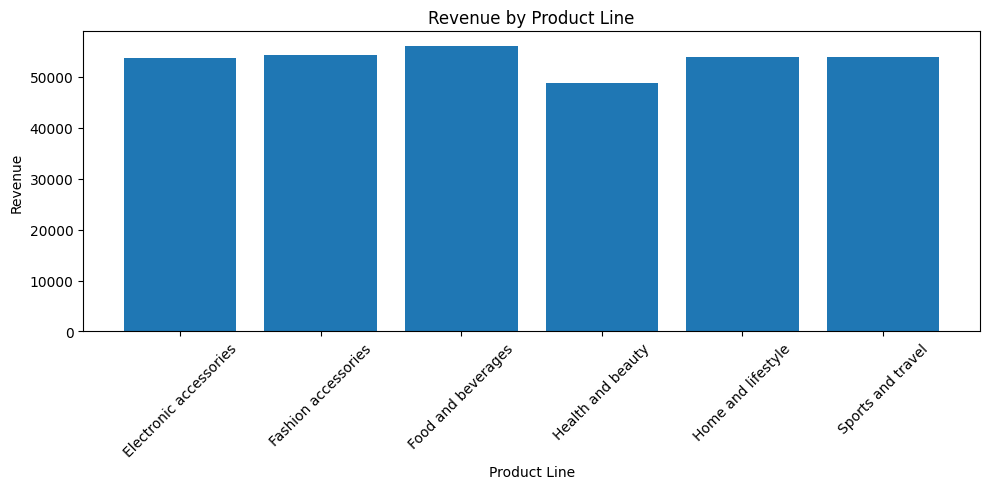

In [16]:
plt.figure(figsize=(10,5))
plt.bar(sales_summary["product"],
        sales_summary["revenue"])
plt.title("Revenue by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()